In [1]:
import os
import re
import glob
import json
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy.stats import hypergeom, spearmanr

In [2]:
INPUT = "/kaggle/input/datasets/nocturnalnerd18"
OUT_DIR = "/kaggle/working/dla_llava_analysis"
os.makedirs(OUT_DIR, exist_ok=True)

TYPES = ["attribute", "object", "relation"]
N_LAYER, N_HEAD = 32, 32
N_COMP = N_LAYER * N_HEAD + N_LAYER + 1

MIN_GROUP = 10
MIN_BIN = 5
N_BINS = 8
N_PERM = 500
K_TOP = 20
MIN_LOGITS = 0.05

CONTRASTS = {
    "flip": ("false_yes", "true_no", 1),
    "evidence": ("false_yes", "true_yes", 1),
    "evidence_matched": ("false_yes", "true_yes", N_BINS),
}
UNITS = {
    "attribute": ("attribute", None),
    "object": ("object", None),
    "relation/reefknot": ("relation", "reefknot"),
    "relation/amber": ("relation", "amber"),
}
PLOT_UNITS = ["attribute", "object", "relation/reefknot"]


def batch_number(path):
    return int(re.search(r"_batch_(\d+)\.pt$", path).group(1))


meta, attn, mlp, embed, logit_diff = [], [], [], [], []
for t in TYPES:
    for path in sorted(glob.glob(f"{INPUT}/dla-llava/{t}_batch_*.pt"), key=batch_number):
        for e in torch.load(path):
            meta.append({k: e[k] for k in ("question_id", "hallucination_type", "ground_truth_answer")})
            attn.append(e["attn"] / e["rms"])
            mlp.append(e["mlp"] / e["rms"])
            embed.append((e["embed"] / e["rms"]).item())
            logit_diff.append(e["logit_diff"].item())

dla = pd.DataFrame(meta)
dla["row"] = np.arange(len(dla))
dla["logit_diff"] = logit_diff
FEATURES = np.concatenate([
    torch.stack(attn).reshape(len(dla), -1).numpy(),
    torch.stack(mlp).numpy(),
    np.array(embed, dtype=np.float32)[:, None],
], axis=1).astype(np.float32)

completeness_err = np.abs(FEATURES.sum(1) - dla["logit_diff"].to_numpy()).max()
print(len(dla), "dla entries,", FEATURES.shape[1], "components each")
print(f"components vs model logit diff, max abs err: {completeness_err:.4f}")
assert completeness_err < 0.5, "components do not reproduce the logit difference"

17134 dla entries, 1057 components each
components vs model logit diff, max abs err: 0.0175


In [3]:
with open(f"{INPUT}/vlm-labeled-examples/labeled_examples.json") as f:
    labels = pd.DataFrame(json.load(f))
assert "cache" in labels.columns, "attach vlm-labeled-examples version 3"
labels = labels[labels["cache"] == "question_aware"][["question_id", "source", "split", "model_answer"]]

df = dla.merge(labels, on="question_id", how="inner")
print(len(dla), "dla entries,", len(labels), "labeled yes/no questions,", len(df), "joined")
assert len(df) == len(labels), "labeled questions missing from dla"

df["truth"] = df["ground_truth_answer"].str.strip().str.lower()
df["group"] = np.select(
    [
        (df.truth == "yes") & (df.model_answer == "yes"),
        (df.truth == "no") & (df.model_answer == "no"),
        (df.truth == "no") & (df.model_answer == "yes"),
        (df.truth == "yes") & (df.model_answer == "no"),
    ],
    ["true_yes", "true_no", "false_yes", "false_no"],
    default="other",
)
assert (df.group != "other").all()

agree = ((df.logit_diff > 0) == (df.model_answer == "yes")).mean()
print(f"sign of logit_diff agrees with model_answer: {agree:.4f}")
assert agree > 0.95, "logit_diff disagrees with the cached answers"


def unit_mask(unit):
    t, source = UNITS[unit]
    mask = df.hallucination_type.eq(t)
    if source is not None:
        mask &= df.source.eq(source)
    return mask


def count_rows(unit, group, splits):
    return int((unit_mask(unit) & df.group.eq(group) & df.split.isin(splits)).sum())


print(pd.crosstab([df.hallucination_type, df.source, df.split], df.group))

17134 dla entries, 17126 labeled yes/no questions, 17126 joined
sign of logit_diff agrees with model_answer: 1.0000
group                              false_no  false_yes  true_no  true_yes
hallucination_type source   split                                        
attribute          amber    test         39        262      305       529
                            train       211       1207     1463      2460
                            val          39        267      305       533
object             pope     test         20         27      198       205
                            train        84        135      915       966
                            val          21         32      193       204
relation           amber    test         42         14       83       107
                            train       232        107      377       447
                            val          50         24       84        97
                   reefknot test         80        192      175       

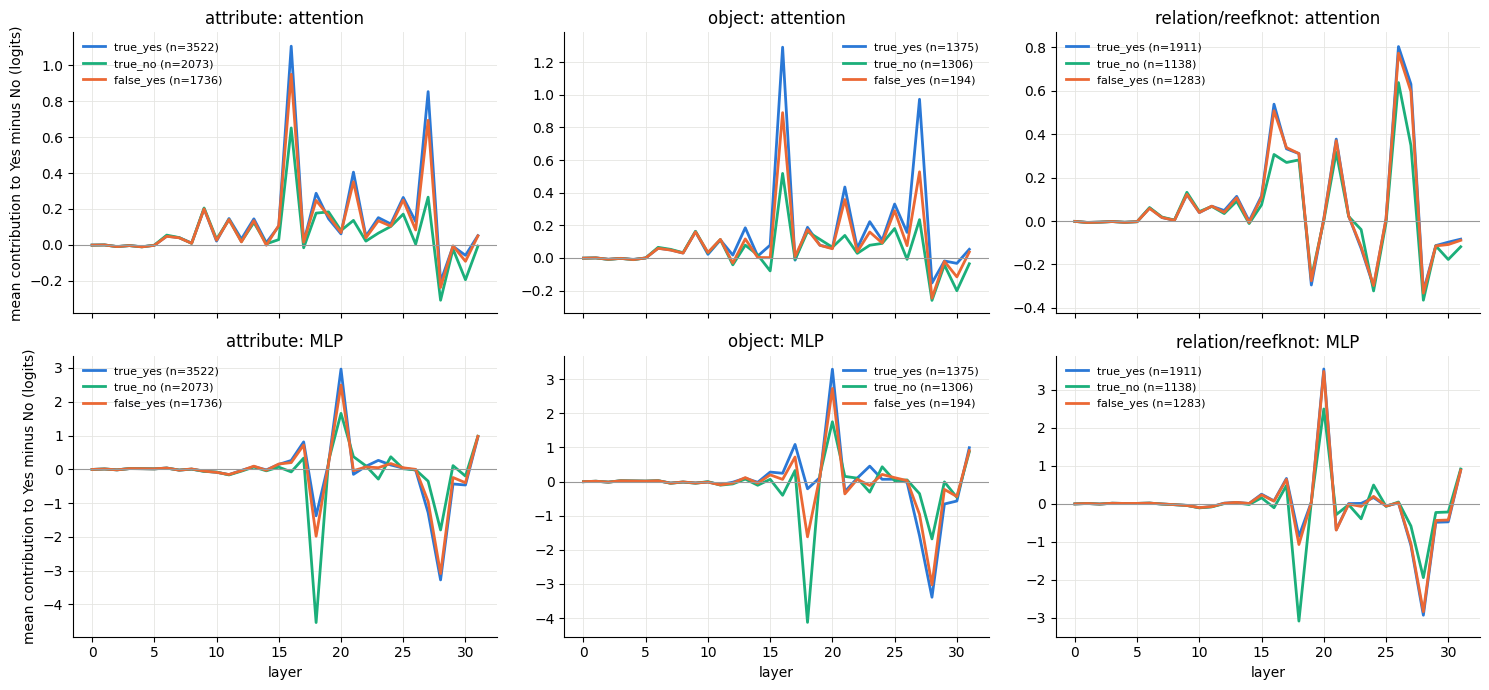

In [4]:
GROUP_COLORS = {"true_yes": "#2a78d6", "true_no": "#1baf7a", "false_yes": "#eb6834"}
UNIT_COLORS = {"attribute": "#2a78d6", "object": "#eb6834", "relation/reefknot": "#1baf7a"}
layer_axis = np.arange(N_LAYER)
attn_layer = FEATURES[:, :N_LAYER * N_HEAD].reshape(-1, N_LAYER, N_HEAD).sum(2)
mlp_layer = FEATURES[:, N_LAYER * N_HEAD:N_LAYER * N_HEAD + N_LAYER]

fig, axes = plt.subplots(2, len(PLOT_UNITS), figsize=(5 * len(PLOT_UNITS), 7), sharex=True)
for col, unit in enumerate(PLOT_UNITS):
    for row, (name, arr) in enumerate([("attention", attn_layer), ("MLP", mlp_layer)]):
        ax = axes[row, col]
        for g, color in GROUP_COLORS.items():
            x = arr[df[unit_mask(unit) & df.group.eq(g)].row.to_numpy()]
            if len(x) < 2:
                continue
            m, se = x.mean(0), x.std(0, ddof=1) / np.sqrt(len(x))
            ax.plot(layer_axis, m, color=color, lw=2, label=f"{g} (n={len(x)})")
            ax.fill_between(layer_axis, m - 1.96 * se, m + 1.96 * se, color=color, alpha=0.2, lw=0)
        ax.axhline(0, color="#999999", lw=0.8)
        ax.set_title(f"{unit}: {name}")
        ax.grid(color="#e5e5e2", lw=0.6)
        ax.spines[["top", "right"]].set_visible(False)
        ax.legend(frameon=False, fontsize=8)
        if col == 0:
            ax.set_ylabel("mean contribution to Yes minus No (logits)")
        if row == 1:
            ax.set_xlabel("layer")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/layer_profiles.png", dpi=150)
plt.show()

In [5]:
def comp_name(i):
    if i < N_LAYER * N_HEAD:
        return f"L{i // N_HEAD} H{i % N_HEAD}"
    if i < N_LAYER * N_HEAD + N_LAYER:
        return f"L{i - N_LAYER * N_HEAD} MLP"
    return "embed"


def build_strata(unit, g_a, g_b, splits, n_bins):
    sub_all = df[unit_mask(unit) & df.group.isin([g_a, g_b]) & df.split.isin(splits)]
    strata = []
    for _, sub in sub_all.groupby("source"):
        if n_bins > 1:
            edges = np.quantile(sub.logit_diff, np.linspace(0, 1, n_bins + 1)[1:-1])
            parts = [p for _, p in sub.groupby(np.digitize(sub.logit_diff, edges))]
            min_group = MIN_BIN
        else:
            parts, min_group = [sub], MIN_GROUP
        for part in parts:
            is_a = part.group.eq(g_a).to_numpy()
            if is_a.sum() < min_group or (~is_a).sum() < min_group:
                continue
            X = FEATURES[part.row.to_numpy()].astype(np.float64)
            strata.append((X, X ** 2, is_a))
    return strata


def effects(strata, masks):
    d_sum, m_sum, w_sum = np.zeros(N_COMP), np.zeros(N_COMP), 0.0
    for (X, X2, _), mask in zip(strata, masks):
        na, nb = mask.sum(), (~mask).sum()
        mf = mask.astype(np.float64)
        sa, sa2 = mf @ X, mf @ X2
        sb, sb2 = X.sum(0) - sa, X2.sum(0) - sa2
        ma, mb = sa / na, sb / nb
        va, vb = (sa2 - na * ma ** 2) / (na - 1), (sb2 - nb * mb ** 2) / (nb - 1)
        sp = np.sqrt(np.maximum(((na - 1) * va + (nb - 1) * vb) / (na + nb - 2), 0))
        w = na * nb / (na + nb)
        d_sum += w * (ma - mb) / np.maximum(sp, 1e-6)
        m_sum += w * (ma - mb)
        w_sum += w
    return d_sum / w_sum, m_sum / w_sum


def perm_null(strata, seed=0):
    rng = np.random.default_rng(seed)
    null = np.empty(N_PERM)
    for b in range(N_PERM):
        d, _ = effects(strata, [rng.permutation(mask) for _, _, mask in strata])
        null[b] = np.abs(d).max()
    return null

In [6]:
results = {}
for unit in UNITS:
    for cname, (g_a, g_b, n_bins) in CONTRASTS.items():
        train = build_strata(unit, g_a, g_b, ["train"], n_bins)
        held = build_strata(unit, g_a, g_b, ["val", "test"], n_bins)
        if not train or not held:
            print(f"{unit:18s} {cname:17s} not enough examples, skipped")
            continue
        d_train, m_train = effects(train, [m for _, _, m in train])
        d_held, m_held = effects(held, [m for _, _, m in held])
        null95 = float(np.quantile(perm_null(train), 0.95))
        n_a = int(sum(m.sum() for _, _, m in train))
        n_b = int(sum((~m).sum() for _, _, m in train))
        material = (
            (np.abs(d_train) > null95) & (np.sign(m_train) == np.sign(m_held)) & (np.abs(m_train) >= MIN_LOGITS)
        )
        results[(unit, cname)] = {
            "d_train": d_train, "m_train": m_train, "d_held": d_held, "m_held": m_held,
            "null95": null95, "n_a": n_a, "n_b": n_b, "material": material,
        }
        print(f"{unit:18s} {cname:17s} {g_a} {n_a}/{count_rows(unit, g_a, ['train'])} vs {g_b} {n_b} | "
              f"residual logit gap {m_train.sum():+.3f} | null95 {null95:.3f} | "
              f"significant {int((np.abs(d_train) > null95).sum())} | material {int(material.sum())}")

attribute          flip              false_yes 1207/1207 vs true_no 1463 | residual logit gap +3.007 | null95 0.157 | significant 649 | material 24
attribute          evidence          false_yes 1207/1207 vs true_yes 2460 | residual logit gap -1.067 | null95 0.143 | significant 546 | material 12
attribute          evidence_matched  false_yes 1207/1207 vs true_yes 2460 | residual logit gap -0.040 | null95 0.152 | significant 530 | material 7
object             flip              false_yes 135/135 vs true_no 915 | residual logit gap +3.396 | null95 0.371 | significant 570 | material 24
object             evidence          false_yes 135/135 vs true_yes 966 | residual logit gap -3.102 | null95 0.371 | significant 441 | material 21
object             evidence_matched  false_yes 129/135 vs true_yes 283 | residual logit gap -0.094 | null95 0.465 | significant 73 | material 0
relation/reefknot  flip              false_yes 901/901 vs true_no 784 | residual logit gap +2.156 | null95 0.194 | signi

In [7]:
for (unit, cname), r in results.items():
    gap = r["m_train"].sum()
    top = np.argsort(-np.abs(r["m_train"]))[:K_TOP]
    print(f"--- {unit} / {cname}: {r['n_a']} vs {r['n_b']} train questions, mean logit gap {gap:+.3f} ---")
    print(f"material components: {int(r['material'].sum())} | top-{K_TOP} by logits net {r['m_train'][top].sum():+.3f} of the gap")
    table = pd.DataFrame({
        "component": [comp_name(i) for i in top[:10]],
        "logits_train": r["m_train"][top[:10]].round(3),
        "logits_held": r["m_held"][top[:10]].round(3),
        "d_train": r["d_train"][top[:10]].round(2),
        "material": r["material"][top[:10]],
    })
    print(table.to_string(index=False))

--- attribute / flip: 1207 vs 1463 train questions, mean logit gap +3.007 ---
material components: 24 | top-20 by logits net +2.479 of the gap
component  logits_train  logits_held  d_train  material
  L18 MLP         2.559        2.540     2.53      True
  L28 MLP        -1.296       -1.284    -2.25      True
  L20 MLP         0.843        0.823     1.87      True
  L27 MLP        -0.600       -0.598    -2.31      True
   L27 H7         0.418        0.419     1.90      True
  L21 MLP        -0.416       -0.417    -1.31      True
  L17 MLP         0.388        0.388     2.29      True
  L29 MLP        -0.354       -0.348    -1.67      True
  L23 MLP         0.343        0.323     1.47      True
  L16 MLP         0.275        0.276     1.68      True
--- attribute / evidence: 1207 vs 2460 train questions, mean logit gap -1.067 ---
material components: 12 | top-20 by logits net -0.919 of the gap
component  logits_train  logits_held  d_train  material
  L18 MLP        -0.602       -0.613  

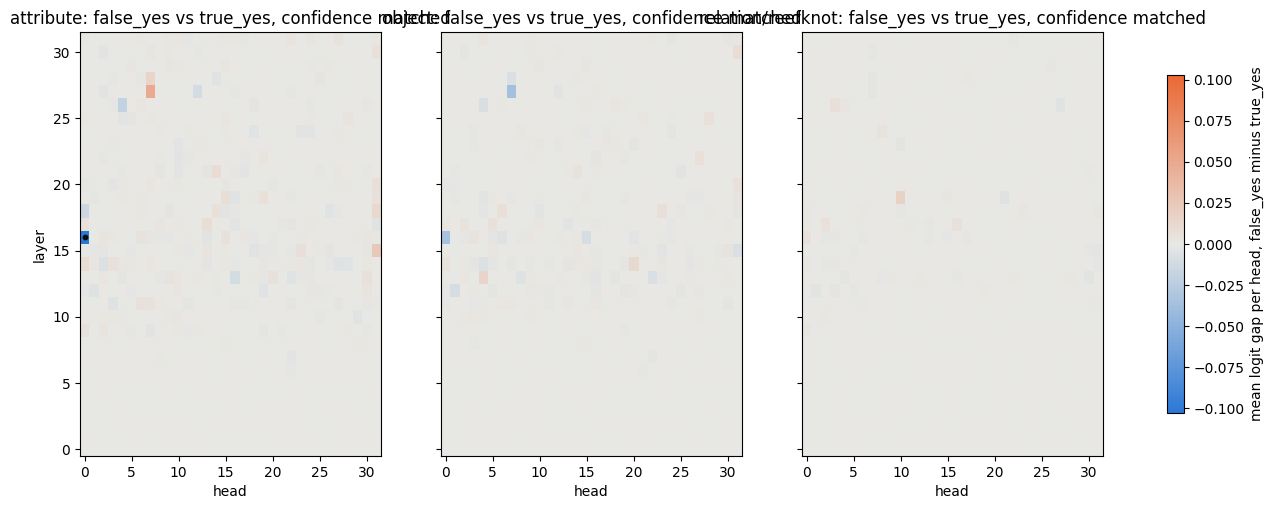

In [8]:
DIVERGING = LinearSegmentedColormap.from_list("dla_div", ["#2a78d6", "#e8e8e4", "#eb6834"])
plot_units = [u for u in PLOT_UNITS if (u, "evidence_matched") in results]
head_m = {u: results[(u, "evidence_matched")]["m_train"][:N_LAYER * N_HEAD] for u in plot_units}
limit = max(np.abs(v).max() for v in head_m.values())

fig, axes = plt.subplots(1, len(plot_units), figsize=(5.5 * len(plot_units), 5.5), sharey=True, squeeze=False)
for ax, unit in zip(axes[0], plot_units):
    im = ax.imshow(head_m[unit].reshape(N_LAYER, N_HEAD), origin="lower", cmap=DIVERGING, vmin=-limit, vmax=limit, aspect="auto")
    ys, xs = np.nonzero(results[(unit, "evidence_matched")]["material"][:N_LAYER * N_HEAD].reshape(N_LAYER, N_HEAD))
    ax.scatter(xs, ys, s=10, color="#0b0b0b")
    ax.set_title(f"{unit}: false_yes vs true_yes, confidence matched")
    ax.set_xlabel("head")
axes[0, 0].set_ylabel("layer")
fig.colorbar(im, ax=axes.ravel().tolist(), label="mean logit gap per head, false_yes minus true_yes", shrink=0.8)
plt.savefig(f"{OUT_DIR}/head_effects_matched.png", dpi=150, bbox_inches="tight")
plt.show()

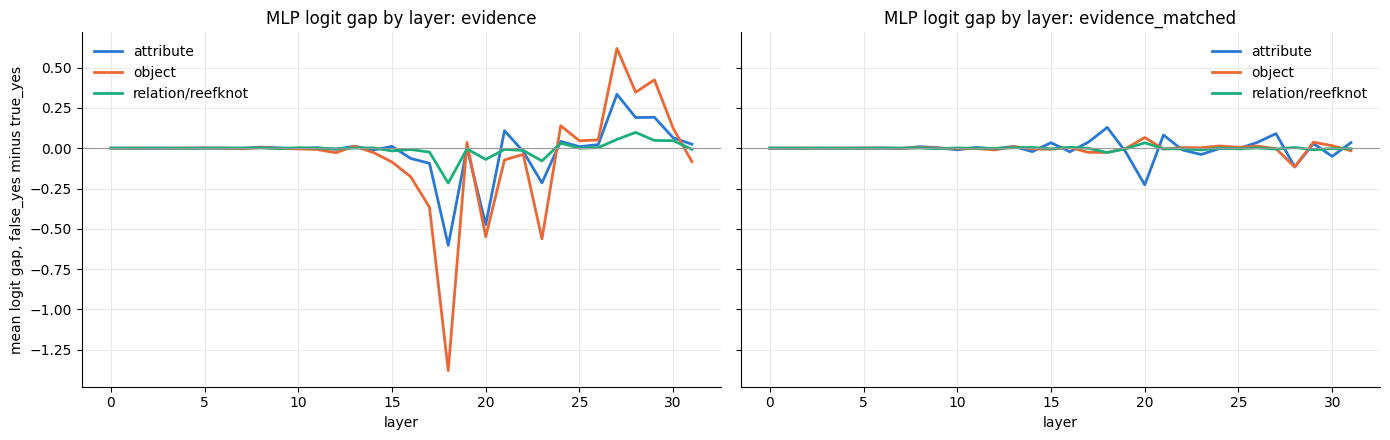

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), sharey=True)
for ax, cname in zip(axes, ["evidence", "evidence_matched"]):
    for unit in PLOT_UNITS:
        if (unit, cname) not in results:
            continue
        r = results[(unit, cname)]
        ax.plot(layer_axis, r["m_train"][N_LAYER * N_HEAD:N_LAYER * N_HEAD + N_LAYER], color=UNIT_COLORS[unit], lw=2, label=unit)
    ax.axhline(0, color="#999999", lw=0.8)
    ax.set_title(f"MLP logit gap by layer: {cname}")
    ax.set_xlabel("layer")
    ax.grid(color="#e5e5e2", lw=0.6)
    ax.spines[["top", "right"]].set_visible(False)
    ax.legend(frameon=False)
axes[0].set_ylabel("mean logit gap, false_yes minus true_yes")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/mlp_effects.png", dpi=150)
plt.show()

In [10]:
PAIRS = [
    ("attribute", "object"), ("attribute", "relation/reefknot"), ("object", "relation/reefknot"),
    ("relation/amber", "relation/reefknot"),
]

for cname in CONTRASTS:
    print(f"--- {cname}: top-{K_TOP} overlap by logit contribution ---")
    for a, b in PAIRS:
        if (a, cname) not in results or (b, cname) not in results:
            continue
        ma, mb = results[(a, cname)]["m_train"], results[(b, cname)]["m_train"]
        top_a, top_b = set(np.argsort(-np.abs(ma))[:K_TOP]), set(np.argsort(-np.abs(mb))[:K_TOP])
        overlap = len(top_a & top_b)
        p = hypergeom.sf(overlap - 1, N_COMP, K_TOP, K_TOP)
        print(f"{a:18s} vs {b:18s} overlap {overlap}/{K_TOP} (chance {K_TOP * K_TOP / N_COMP:.1f}, p {p:.4f}) | "
              f"spearman logits {spearmanr(ma, mb)[0]:.3f} | spearman |logits| {spearmanr(np.abs(ma), np.abs(mb))[0]:.3f} | "
              f"false_yes train {results[(a, cname)]['n_a']} / {results[(b, cname)]['n_a']}")

--- flip: top-20 overlap by logit contribution ---
attribute          vs object             overlap 17/20 (chance 0.4, p 0.0000) | spearman logits 0.603 | spearman |logits| 0.797 | false_yes train 1207 / 135
attribute          vs relation/reefknot  overlap 16/20 (chance 0.4, p 0.0000) | spearman logits 0.533 | spearman |logits| 0.769 | false_yes train 1207 / 901
object             vs relation/reefknot  overlap 16/20 (chance 0.4, p 0.0000) | spearman logits 0.554 | spearman |logits| 0.755 | false_yes train 135 / 901
relation/amber     vs relation/reefknot  overlap 16/20 (chance 0.4, p 0.0000) | spearman logits 0.338 | spearman |logits| 0.700 | false_yes train 107 / 901
--- evidence: top-20 overlap by logit contribution ---
attribute          vs object             overlap 17/20 (chance 0.4, p 0.0000) | spearman logits 0.546 | spearman |logits| 0.792 | false_yes train 1207 / 135
attribute          vs relation/reefknot  overlap 14/20 (chance 0.4, p 0.0000) | spearman logits 0.276 | spearma

In [11]:
shortlist = {}
for (unit, cname), r in results.items():
    keep = [i for i in np.argsort(-np.abs(r["m_train"])) if r["material"][i]]
    shortlist[f"{unit}/{cname}"] = [
        {"component": comp_name(i), "index": int(i), "logits_train": float(r["m_train"][i]),
         "logits_held": float(r["m_held"][i]), "d_train": float(r["d_train"][i]), "d_held": float(r["d_held"][i])}
        for i in keep[:30]
    ]
    print(f"{unit:18s} {cname:17s} shortlisted {len(shortlist[f'{unit}/{cname}'])} of {int(r['material'].sum())} material")

with open(f"{OUT_DIR}/shortlist.json", "w") as f:
    json.dump(shortlist, f)

with open(f"{OUT_DIR}/effects.json", "w") as f:
    json.dump({
        f"{unit}/{cname}": {
            "d_train": r["d_train"].tolist(), "d_held": r["d_held"].tolist(),
            "m_train": r["m_train"].tolist(), "m_held": r["m_held"].tolist(),
            "material": np.flatnonzero(r["material"]).tolist(),
            "null95": r["null95"], "n_a": r["n_a"], "n_b": r["n_b"],
        }
        for (unit, cname), r in results.items()
    }, f)

attribute          flip              shortlisted 24 of 24 material
attribute          evidence          shortlisted 12 of 12 material
attribute          evidence_matched  shortlisted 7 of 7 material
object             flip              shortlisted 24 of 24 material
object             evidence          shortlisted 21 of 21 material
object             evidence_matched  shortlisted 0 of 0 material
relation/reefknot  flip              shortlisted 18 of 18 material
relation/reefknot  evidence          shortlisted 5 of 5 material
relation/reefknot  evidence_matched  shortlisted 0 of 0 material
relation/amber     flip              shortlisted 11 of 11 material
relation/amber     evidence          shortlisted 6 of 6 material
relation/amber     evidence_matched  shortlisted 3 of 3 material


In [12]:
USERNAME = "nocturnalnerd18"

with open(os.path.join(OUT_DIR, "dataset-metadata.json"), "w") as f:
    json.dump({
        "title": "dla-llava-analysis",
        "id": f"{USERNAME}/dla-llava-analysis",
        "subtitle": "DLA effect sizes and shortlisted components for LLaVA",
        "description": "Per-component effects for every attention head, MLP layer and the embedding on three contrasts: "
                       "flip (false_yes vs true_no), evidence (false_yes vs true_yes) and evidence_matched (false_yes vs true_yes "
                       "within bins of the model's own Yes minus No logit). Units are attribute, object, relation/reefknot and "
                       "relation/amber. m_* vectors are mean logit gaps and d_* vectors are Cohen's d, ranked on train and checked "
                       "on val and test. Components are indexed as layer * 32 + head for heads, 1024 + layer for MLPs and 1056 "
                       "for the embedding. shortlist.json holds material components: they pass a max-statistic permutation null "
                       "on train, keep their sign on held-out data and contribute at least 0.05 logits.",
        "licenses": [{"name": "CC0-1.0"}],
    }, f)

!kaggle datasets version -p {OUT_DIR} -m "v2: logit-ranked shortlist, confidence-matched evidence contrast, relation per source"

Starting upload for file effects.json
100%|██████████████████████████████████████| 1.09M/1.09M [00:01<00:00, 1.11MB/s]
Upload successful: effects.json (1MB)
Starting upload for file mlp_effects.png
100%|█████████████████████████████████████████| 109k/109k [00:00<00:00, 220kB/s]
Upload successful: mlp_effects.png (109KB)
Starting upload for file head_effects_matched.png
100%|███████████████████████████████████████| 72.0k/72.0k [00:00<00:00, 178kB/s]
Upload successful: head_effects_matched.png (72KB)
Starting upload for file layer_profiles.png
100%|█████████████████████████████████████████| 333k/333k [00:00<00:00, 438kB/s]
Upload successful: layer_profiles.png (333KB)
Starting upload for file shortlist.json
100%|██████████████████████████████████████| 22.7k/22.7k [00:00<00:00, 61.9kB/s]
Upload successful: shortlist.json (23KB)
Dataset version is being created. Please check progress at https://www.kaggle.com/datasets/nocturnalnerd18/dla-llava-analysis
